In [1]:
!pip install -q tensorflow scikit-image scikit-learn opencv-python mediapipe pillow matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [2]:
import os
import gc
import cv2
import json
import time
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from skimage.feature import hog
from skimage.transform import resize

import mediapipe as mp
from mediapipe.tasks.python import vision, BaseOptions

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, balanced_accuracy_score
)
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))
print('CPUs:', len(tf.config.list_physical_devices('CPU')))

TensorFlow: 2.20.0
GPUs: []
CPUs: 1


2026-09-17 10:12:32.258132: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
DATASET_PATH = "/kaggle/input/datasets/navneet0094/jafee-dataset-fo/jaffe" 
OUT_SIZE = 128
CNN_SIZE = 160

EMOTION_MAP = {
    'AN': 0, 'DI': 1, 'FE': 2,
    'HA': 3, 'SA': 4, 'SU': 5, 'NE': 6
}
EMOTION_NAMES = ['Anger', 'Disgust', 'Fear', 'Happy', 'Sadness', 'Surprise', 'Neutral']
NUM_EMOTIONS = len(EMOTION_NAMES)

LEFT_EYE_CORNER = 33
RIGHT_EYE_CORNER = 133

# Training controls
N_SPLITS = 5
USE_SUBJECT_INDEPENDENT_CV = False  # Recommended for final research evaluation
WARMUP_EPOCHS = 5                    # Frozen backbone warm-up
FINE_TUNE_EPOCHS = 30
TOTAL_EPOCHS_CAP = WARMUP_EPOCHS + FINE_TUNE_EPOCHS
TRAINING_BATCH_SIZE = 8              # Keep small for CPU/RAM safety
FINE_TUNE_LAST_N = 30                 # Number of final MobileNetV2 layers made trainable
WARMUP_LR = 1e-3
FINE_TUNE_LR = 1e-5
DROPOUT = 0.35

print('Dataset:', DATASET_PATH)
print('Fine-tune last', FINE_TUNE_LAST_N, 'MobileNetV2 layers')

Dataset: /kaggle/input/datasets/navneet0094/jafee-dataset-fo/jaffe
Fine-tune last 30 MobileNetV2 layers


In [4]:
def load_jaffe_dataset(dataset_path):
    raw_images, labels, subjects, filenames = [], [], [], []
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(f'Dataset path not found: {dataset_path}')

    files = [f for f in os.listdir(dataset_path)
             if f.lower().endswith(('.tiff', '.tif', '.jpg', '.jpeg', '.png'))]

    for filename in sorted(files):
        parts = filename.split('.')
        if len(parts) < 3:
            continue
        emotion_code = parts[1][:2]
        if emotion_code not in EMOTION_MAP:
            continue
        subject = parts[0]
        img = np.array(Image.open(os.path.join(dataset_path, filename)).convert('RGB'), dtype=np.uint8)
        raw_images.append(img)
        labels.append(EMOTION_MAP[emotion_code])
        subjects.append(subject)
        filenames.append(filename)

    # Converting them to np.array(..., dtype=object) breaks plotting functions such as imshow().
    return raw_images, np.array(labels), np.array(subjects), np.array(filenames)

raw_images, labels, subjects, filenames = load_jaffe_dataset(DATASET_PATH)
print(f'Loaded {len(raw_images)} images')
print('Subjects:', len(np.unique(subjects)))
print(pd.Series(labels).map(dict(enumerate(EMOTION_NAMES))).value_counts().sort_index())

Loaded 213 images
Subjects: 10
Anger       30
Disgust     29
Fear        32
Happy       31
Neutral     30
Sadness     31
Surprise    30
Name: count, dtype: int64


In [5]:
print('First image:', type(raw_images[0]).__name__, raw_images[0].shape, raw_images[0].dtype)
assert raw_images[0].ndim == 3 and raw_images[0].shape[-1] == 3


First image: ndarray (256, 256, 3) uint8


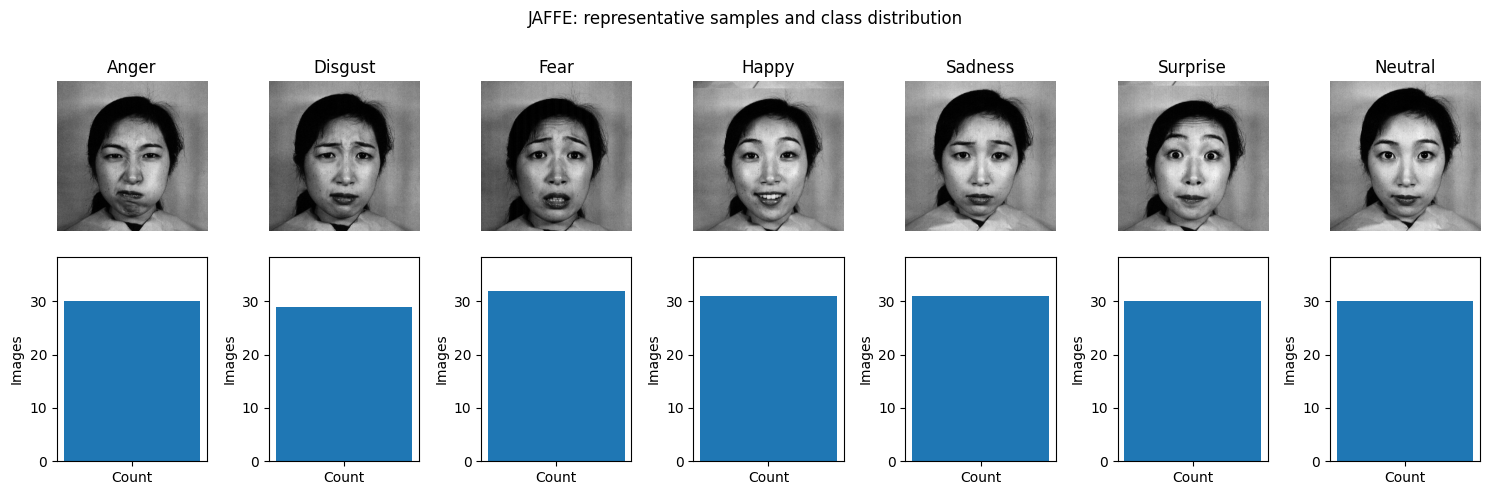

In [6]:
# Representative sample grid + class counts
fig, axes = plt.subplots(2, 7, figsize=(15, 5))
for emotion_id, emotion in enumerate(EMOTION_NAMES):
    idxs = np.where(labels == emotion_id)[0]
    idx = idxs[0]
    axes[0, emotion_id].imshow(raw_images[idx])
    axes[0, emotion_id].set_title(emotion)
    axes[0, emotion_id].axis('off')
    axes[1, emotion_id].bar(['Count'], [len(idxs)])
    axes[1, emotion_id].set_ylim(0, max(np.bincount(labels)) * 1.2)
    axes[1, emotion_id].set_ylabel('Images')
plt.suptitle('JAFFE: representative samples and class distribution')
plt.tight_layout()
plt.show()

## MediaPipe Face Landmarker

In [7]:
MODEL_PATH = 'face_landmarker.task'
MODEL_URL = (
    'https://storage.googleapis.com/mediapipe-models/face_landmarker/'
    'face_landmarker/float16/1/face_landmarker.task'
)
if not os.path.exists(MODEL_PATH):
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

base_options = BaseOptions(model_asset_path=MODEL_PATH)
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    num_faces=1,
)
landmarker = vision.FaceLandmarker.create_from_options(options)
print('MediaPipe Face Landmarker ready')

MediaPipe Face Landmarker ready


W0000 00:00:1789639956.489506      75 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1789639956.505637      80 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789639956.531011      80 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [8]:
def extract_landmarks(images):
    landmarks_list = []
    detected = []
    for img in images:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(img))
        try:
            results = landmarker.detect(mp_image)
            if results.face_landmarks:
                lm = results.face_landmarks[0]
                pts = np.array([[p.x * img.shape[1], p.y * img.shape[0]] for p in lm], dtype=np.float32)
                landmarks_list.append(pts)
                detected.append(True)
                continue
        except Exception:
            pass
        h, w = img.shape[:2]
        landmarks_list.append(np.full((478, 2), [w / 2, h / 2], dtype=np.float32))
        detected.append(False)
    return np.array(landmarks_list), np.array(detected)

landmarks_list, face_detected = extract_landmarks(raw_images)
print('Landmarks:', landmarks_list.shape)
print('Detected:', face_detected.sum(), '/', len(face_detected))

Landmarks: (213, 478, 2)
Detected: 213 / 213


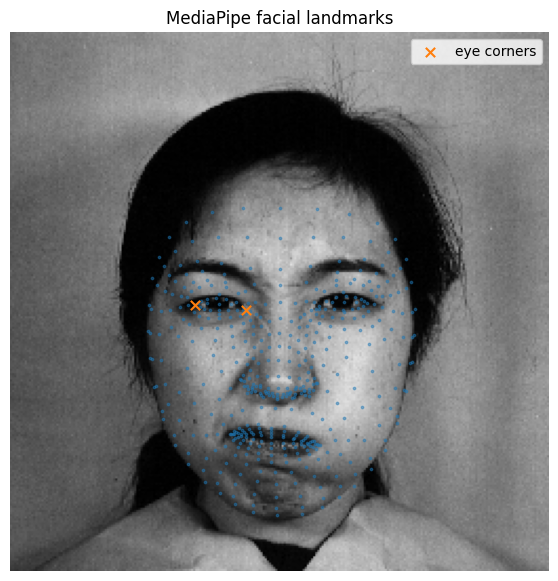

In [9]:
def plot_mediapipe_landmarks(img, landmarks, title='MediaPipe facial landmarks'):
    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.scatter(landmarks[:, 0], landmarks[:, 1], s=3, alpha=0.45)
    plt.scatter([landmarks[LEFT_EYE_CORNER, 0], landmarks[RIGHT_EYE_CORNER, 0]],
                [landmarks[LEFT_EYE_CORNER, 1], landmarks[RIGHT_EYE_CORNER, 1]],
                s=45, marker='x', label='eye corners')
    plt.legend()
    plt.title(title)
    plt.axis('off')
    plt.show()

example_idx = 0
plot_mediapipe_landmarks(raw_images[example_idx], landmarks_list[example_idx])

In [10]:
def align_and_crop(rgb_image, landmarks, out_size=OUT_SIZE, margin=0.25):
    left_eye = landmarks[LEFT_EYE_CORNER]
    right_eye = landmarks[RIGHT_EYE_CORNER]
    dy = right_eye[1] - left_eye[1]
    dx = right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dy, dx))

    h, w = rgb_image.shape[:2]
    center = (w // 2, h // 2)
    rot_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(rgb_image, rot_matrix, (w, h), borderMode=cv2.BORDER_REFLECT)

    landmarks_h = np.column_stack([landmarks, np.ones(len(landmarks))])
    rotated_lm = landmarks_h @ rot_matrix.T

    x_min, x_max = rotated_lm[:, 0].min(), rotated_lm[:, 0].max()
    y_min, y_max = rotated_lm[:, 1].min(), rotated_lm[:, 1].max()
    bw, bh = x_max - x_min, y_max - y_min
    x_min, y_min = x_min - bw * margin, y_min - bh * margin
    x_max, y_max = x_max + bw * margin, y_max + bh * margin

    x_min, y_min = max(0, int(x_min)), max(0, int(y_min))
    x_max, y_max = min(w, int(x_max)), min(h, int(y_max))

    crop = rotated[y_min:y_max, x_min:x_max]
    if crop.size == 0:
        crop = rgb_image
    return cv2.resize(crop, (out_size, out_size), interpolation=cv2.INTER_AREA)


def extract_regions(face_img):
    h = face_img.shape[0]
    return face_img[:h // 2], face_img[h // 2:]

aligned_faces = np.array([
    align_and_crop(img, lm) for img, lm in zip(raw_images, landmarks_list)
])
upper_faces, lower_faces = zip(*[extract_regions(img) for img in aligned_faces])
upper_faces = np.array(upper_faces)
lower_faces = np.array(lower_faces)
print('Aligned:', aligned_faces.shape, '| Upper:', upper_faces.shape, '| Lower:', lower_faces.shape)

Aligned: (213, 128, 128, 3) | Upper: (213, 64, 128, 3) | Lower: (213, 64, 128, 3)


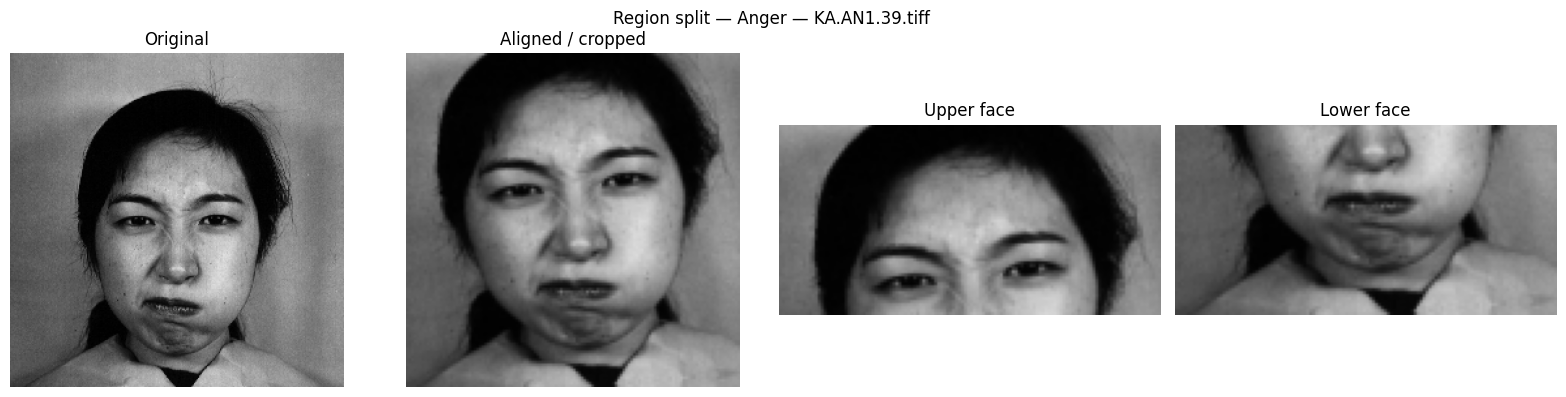

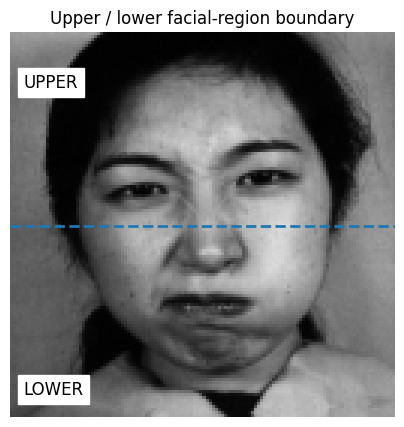

In [11]:
def show_region_pipeline(idx):
    img = aligned_faces[idx]
    upper, lower = extract_regions(img)
    fig, ax = plt.subplots(1, 4, figsize=(16, 4))
    ax[0].imshow(raw_images[idx]); ax[0].set_title('Original'); ax[0].axis('off')
    ax[1].imshow(img); ax[1].set_title('Aligned / cropped'); ax[1].axis('off')
    ax[2].imshow(upper); ax[2].set_title('Upper face'); ax[2].axis('off')
    ax[3].imshow(lower); ax[3].set_title('Lower face'); ax[3].axis('off')
    fig.suptitle(f"Region split — {EMOTION_NAMES[labels[idx]]} — {filenames[idx]}")
    plt.tight_layout(); plt.show()

show_region_pipeline(example_idx)

# Explicit split overlay on the aligned face
plt.figure(figsize=(5, 5))
plt.imshow(aligned_faces[example_idx])
plt.axhline(OUT_SIZE / 2, linewidth=2, linestyle='--')
plt.text(4, 18, 'UPPER', fontsize=12, backgroundcolor='white')
plt.text(4, OUT_SIZE - 8, 'LOWER', fontsize=12, backgroundcolor='white')
plt.title('Upper / lower facial-region boundary')
plt.axis('off')
plt.show()

## 6. HOG features + visualization

In [12]:
def extract_hog(images):
    feats, hog_images = [], []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        feat, hog_img = hog(
            gray,
            orientations=8,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            visualize=True
        )
        feats.append(feat)
        hog_images.append(hog_img)
    return np.array(feats), np.array(hog_images)

X_hog_upper, hog_vis_upper = extract_hog(upper_faces)
X_hog_lower, hog_vis_lower = extract_hog(lower_faces)
print('Upper HOG:', X_hog_upper.shape, '| Lower HOG:', X_hog_lower.shape)

Upper HOG: (213, 3360) | Lower HOG: (213, 3360)


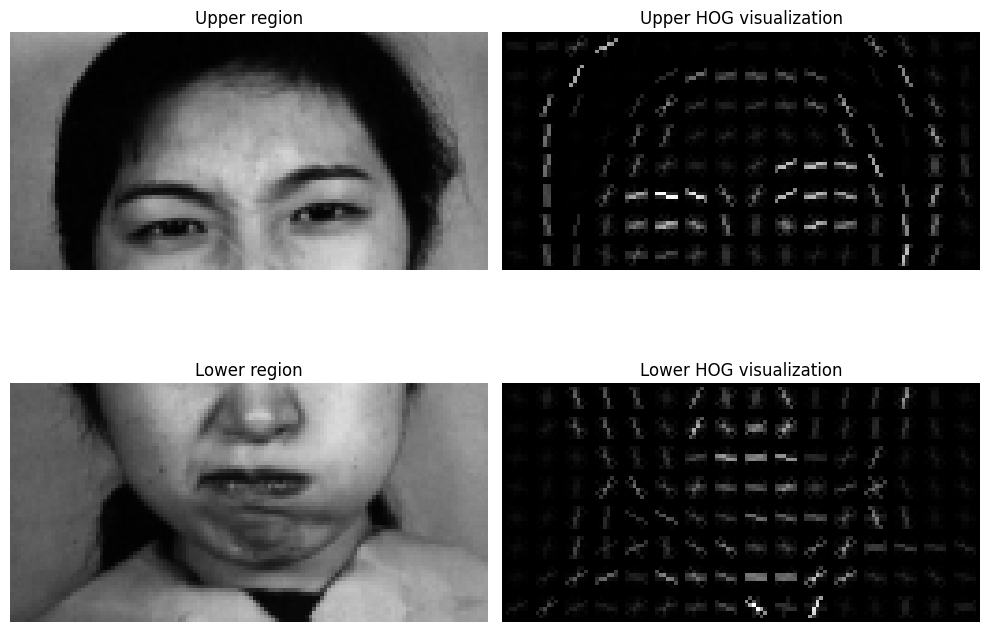

In [13]:
idx = example_idx
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax[0,0].imshow(upper_faces[idx]); ax[0,0].set_title('Upper region'); ax[0,0].axis('off')
ax[0,1].imshow(hog_vis_upper[idx], cmap='gray'); ax[0,1].set_title('Upper HOG visualization'); ax[0,1].axis('off')
ax[1,0].imshow(lower_faces[idx]); ax[1,0].set_title('Lower region'); ax[1,0].axis('off')
ax[1,1].imshow(hog_vis_lower[idx], cmap='gray'); ax[1,1].set_title('Lower HOG visualization'); ax[1,1].axis('off')
plt.tight_layout(); plt.show()

##  Fine-tuned MobileNetV2 + region experts + fusion model

In [14]:
def build_model():
    backbone = MobileNetV2(
        weights='imagenet', include_top=False,
        input_shape=(CNN_SIZE, CNN_SIZE, 3), pooling='avg'
    )
    backbone.trainable = False

    upper_img = keras.Input((CNN_SIZE, CNN_SIZE, 3), name='upper_image')
    lower_img = keras.Input((CNN_SIZE, CNN_SIZE, 3), name='lower_image')
    upper_hog = keras.Input((X_hog_upper.shape[1],), name='hog_upper')
    lower_hog = keras.Input((X_hog_lower.shape[1],), name='hog_lower')

    # Keras preprocessing is applied through preprocess_input before model input.
    upper_cnn = backbone(upper_img)
    lower_cnn = backbone(lower_img)

    upper = layers.Concatenate(name='upper_hog_cnn')([upper_hog, upper_cnn])
    upper = layers.Dense(256, activation='relu')(upper)
    upper = layers.BatchNormalization()(upper)
    upper = layers.Dropout(DROPOUT)(upper)
    upper_embedding = layers.Dense(128, activation='relu', name='upper_embedding')(upper)
    upper = layers.Dropout(DROPOUT)(upper_embedding)
    upper_output = layers.Dense(NUM_EMOTIONS, activation='softmax', name='upper_output')(upper)

    lower = layers.Concatenate(name='lower_hog_cnn')([lower_hog, lower_cnn])
    lower = layers.Dense(256, activation='relu')(lower)
    lower = layers.BatchNormalization()(lower)
    lower = layers.Dropout(DROPOUT)(lower)
    lower_embedding = layers.Dense(128, activation='relu', name='lower_embedding')(lower)
    lower = layers.Dropout(DROPOUT)(lower_embedding)
    lower_output = layers.Dense(NUM_EMOTIONS, activation='softmax', name='lower_output')(lower)

    fusion = layers.Concatenate(name='region_fusion')([upper_output, lower_output])
    fusion = layers.Dense(128, activation='relu')(fusion)
    fusion = layers.Dropout(DROPOUT)(fusion)
    final_output = layers.Dense(NUM_EMOTIONS, activation='softmax', name='final_output')(fusion)

    model = keras.Model(
        inputs=[upper_img, lower_img, upper_hog, lower_hog],
        outputs=final_output,
        name='RegionAware_FineTuned_MobileNetV2'
    )
    return model, backbone

model, backbone = build_model()
model.compile(
    optimizer=keras.optimizers.Adam(WARMUP_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "RegionAware_FineTuned_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ upper_image         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lower_image         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hog_upper           │ (None, 3360)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 1280)      │  2,257,984 │ upper_image[0][0… │
│ (Functional)        │                   │            │ lower_image[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hog_lower           │ (None, 3360)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ upper_hog_cnn       │ (None, 4640)      │          0 │ hog_upper[0][0],  │
│ (Concatenate)       │                   │            │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lower_hog_cnn       │ (None, 4640)      │          0 │ hog_lower[0][0],  │
│ (Concatenate)       │                   │            │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,188,096 │ upper_hog_cnn[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │  1,188,096 │ lower_hog_cnn[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ upper_embedding     │ (None, 128)       │     32,896 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lower_embedding     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ upper_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ lower_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ upper_output        │ (None, 7)         │        903 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lower_output        │ (None, 7)         │        903 │ dropout_3[0][0] 

 Total params: 4,706,645 (17.95 MB)

 Trainable params: 2,447,637 (9.34 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

In [15]:
def set_fine_tune_layers(backbone, last_n=FINE_TUNE_LAST_N):
    backbone.trainable = True
    n = len(backbone.layers)
    cutoff = max(0, n - last_n)
    for i, layer in enumerate(backbone.layers):
        # BatchNorm is kept frozen for stability on the small JAFFE dataset.
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = i >= cutoff
    trainable = sum(int(layer.trainable) for layer in backbone.layers)
    print(f'MobileNetV2 layers: {n} | Trainable after fine-tuning setup: {trainable}')
    return trainable

set_fine_tune_layers(backbone)

MobileNetV2 layers: 155 | Trainable after fine-tuning setup: 20


20

In [16]:
def resize_region_batch(images, size=CNN_SIZE):
    out = np.empty((len(images), size, size, 3), dtype=np.float32)
    for i, img in enumerate(images):
        resized = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA).astype(np.float32)
        out[i] = preprocess_input(resized)
    return out


def make_inputs(indices, scaler_u, scaler_l):
    idx = np.asarray(indices)
    upper = resize_region_batch(upper_faces[idx])
    lower = resize_region_batch(lower_faces[idx])
    hog_u = scaler_u.transform(X_hog_upper[idx]).astype(np.float32)
    hog_l = scaler_l.transform(X_hog_lower[idx]).astype(np.float32)
    return [upper, lower, hog_u, hog_l]


def compile_warmup(model):
    model.compile(
        optimizer=keras.optimizers.Adam(WARMUP_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )


def compile_finetune(model):
    model.compile(
        optimizer=keras.optimizers.Adam(FINE_TUNE_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )


In [17]:
from tensorflow.keras.utils import to_categorical

y_cat = to_categorical(labels, NUM_EMOTIONS)

out_dir = Path('./results_finetuned_jafee')
out_dir.mkdir(exist_ok=True)

if USE_SUBJECT_INDEPENDENT_CV:
    splitter = GroupKFold(n_splits=N_SPLITS)
    split_iter = splitter.split(np.arange(len(labels)), labels, groups=subjects)
else:
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    split_iter = splitter.split(np.arange(len(labels)), labels)

fold_results = []
start_total = time.time()

for fold_num, (train_idx, val_idx) in enumerate(split_iter, start=1):
    print('\n' + '=' * 80)
    print(f'FOLD {fold_num}/{N_SPLITS}')
    print('=' * 80)

    # Leakage-safe feature scaling: fit on training data only.
    scaler_u = StandardScaler().fit(X_hog_upper[train_idx])
    scaler_l = StandardScaler().fit(X_hog_lower[train_idx])

    train_inputs = make_inputs(train_idx, scaler_u, scaler_l)
    val_inputs = make_inputs(val_idx, scaler_u, scaler_l)
    y_train, y_val = y_cat[train_idx], y_cat[val_idx]

    tf.keras.backend.clear_session()
    gc.collect()
    model, backbone = build_model()

    # Stage 1: train the classification head while MobileNetV2 is frozen.
    compile_warmup(model)
    early_warmup = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    )
    history_warmup = model.fit(
        train_inputs, y_train, validation_data=(val_inputs, y_val),
        epochs=WARMUP_EPOCHS, batch_size=TRAINING_BATCH_SIZE,
        callbacks=[early_warmup], verbose=1
    )

    # Stage 2: fine-tune only the last N non-BatchNorm MobileNetV2 layers.
    set_fine_tune_layers(backbone, FINE_TUNE_LAST_N)
    compile_finetune(model)
    early_ft = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=6, restore_best_weights=True
    )
    history_ft = model.fit(
        train_inputs, y_train, validation_data=(val_inputs, y_val),
        epochs=FINE_TUNE_EPOCHS, batch_size=TRAINING_BATCH_SIZE,
        callbacks=[early_ft], verbose=1
    )

    pred_prob = model.predict(val_inputs, verbose=0)
    pred = np.argmax(pred_prob, axis=1)
    true = labels[val_idx]

    acc = accuracy_score(true, pred)
    f1 = f1_score(true, pred, average='macro', zero_division=0)
    bal = balanced_accuracy_score(true, pred)

    weight_path = out_dir / f'fold_{fold_num}.weights.h5'
    model.save_weights(weight_path)

    fold_results.append({
        'fold': fold_num,
        'train_idx': train_idx,
        'val_idx': val_idx,
        'true': true,
        'pred': pred,
        'prob': pred_prob,
        'accuracy': acc,
        'f1': f1,
        'balanced_acc': bal,
        'history_warmup': history_warmup.history,
        'history_finetune': history_ft.history,
        'weights_path': str(weight_path),
    })

    print(f'Fold {fold_num}: accuracy={acc*100:.2f}% | macro-F1={f1:.4f} | balanced={bal:.4f}')

    del model, backbone, train_inputs, val_inputs
    gc.collect()

print(f'\nTotal time: {(time.time()-start_total)/3600:.2f} hours')



FOLD 1/5
Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 372ms/step - accuracy: 0.2176 - loss: 1.9368 - val_accuracy: 0.2558 - val_loss: 1.9073
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 217ms/step - accuracy: 0.2882 - loss: 1.8628 - val_accuracy: 0.2791 - val_loss: 1.8459
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.4000 - loss: 1.7882 - val_accuracy: 0.3721 - val_loss: 1.8041
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step - accuracy: 0.5235 - loss: 1.7088 - val_accuracy: 0.4884 - val_loss: 1.7653
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.6412 - loss: 1.5717 - val_accuracy: 0.3953 - val_loss: 1.7274
MobileNetV2 layers: 155 | Trainable after fine-tuning setup: 20
Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 393ms/step - accuracy: 0.6529 - loss: 1.4984 - val_accuracy: 0.4419 - val_loss: 1.7210
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 237ms/step - accuracy: 0.6529 - loss: 1.5019 - val_accuracy: 0.4419 - val_loss: 1.7150
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━

## 11. Cross-validation results

In [18]:
results_df = pd.DataFrame([
    {
        'Fold': r['fold'],
        'Accuracy %': r['accuracy'] * 100,
        'Macro F1': r['f1'],
        'Balanced Acc': r['balanced_acc']
    }
    for r in fold_results
])
print(results_df.to_string(index=False))
print('\nMean accuracy: %.2f ± %.2f%%' % (results_df['Accuracy %'].mean(), results_df['Accuracy %'].std()))
print('Mean macro-F1: %.4f ± %.4f' % (results_df['Macro F1'].mean(), results_df['Macro F1'].std()))


 Fold  Accuracy %  Macro F1  Balanced Acc
    1   44.186047  0.469388      0.442177
    2   65.116279  0.667063      0.649660
    3   62.790698  0.576557      0.632653
    4   57.142857  0.517150      0.571429
    5   64.285714  0.621800      0.653741

Mean accuracy: 58.70 ± 8.69%
Mean macro-F1: 0.5704 ± 0.0792


In [19]:
# Aggregate out-of-fold predictions
all_true = np.concatenate([r['true'] for r in fold_results])
all_pred = np.concatenate([r['pred'] for r in fold_results])
all_prob = np.concatenate([r['prob'] for r in fold_results])

print(classification_report(all_true, all_pred, target_names=EMOTION_NAMES, digits=4, zero_division=0))

              precision    recall  f1-score   support

       Anger     0.6667    0.8000    0.7273        30
     Disgust     0.8333    0.8621    0.8475        29
        Fear     0.5600    0.4375    0.4912        32
       Happy     0.5455    0.5806    0.5625        31
     Sadness     0.4583    0.3548    0.4000        31
    Surprise     0.6061    0.6667    0.6349        30
     Neutral     0.4062    0.4333    0.4194        30

    accuracy                         0.5869       213
   macro avg     0.5823    0.5907    0.5832       213
weighted avg     0.5802    0.5869    0.5802       213



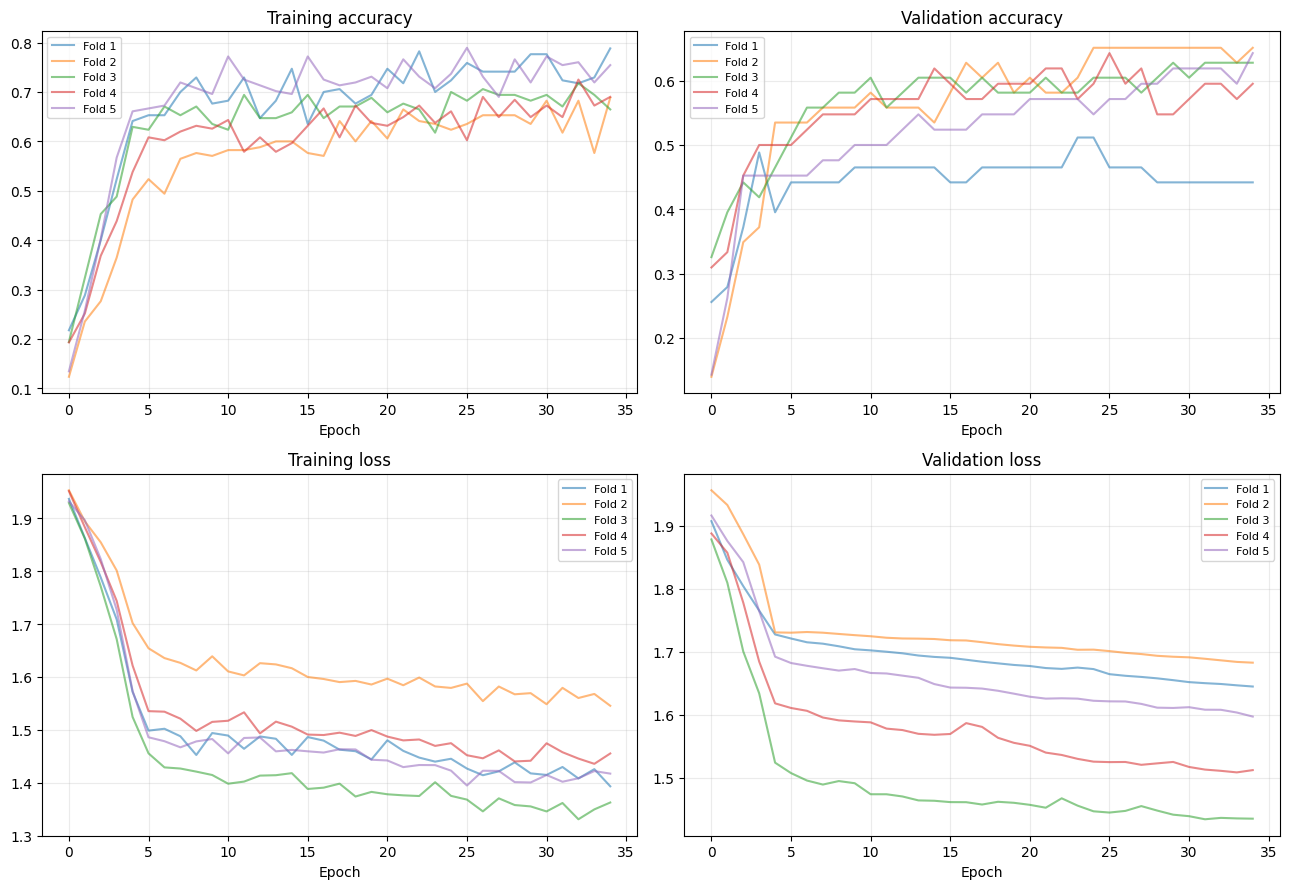

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for r in fold_results:
    hw, hf = r['history_warmup'], r['history_finetune']
    acc = hw['accuracy'] + hf['accuracy']
    val_acc = hw['val_accuracy'] + hf['val_accuracy']
    loss = hw['loss'] + hf['loss']
    val_loss = hw['val_loss'] + hf['val_loss']
    axes[0,0].plot(acc, alpha=0.55, label=f'Fold {r["fold"]}')
    axes[0,1].plot(val_acc, alpha=0.55, label=f'Fold {r["fold"]}')
    axes[1,0].plot(loss, alpha=0.55, label=f'Fold {r["fold"]}')
    axes[1,1].plot(val_loss, alpha=0.55, label=f'Fold {r["fold"]}')
axes[0,0].set_title('Training accuracy')
axes[0,1].set_title('Validation accuracy')
axes[1,0].set_title('Training loss')
axes[1,1].set_title('Validation loss')
for ax in axes.ravel():
    ax.set_xlabel('Epoch'); ax.grid(alpha=0.25); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

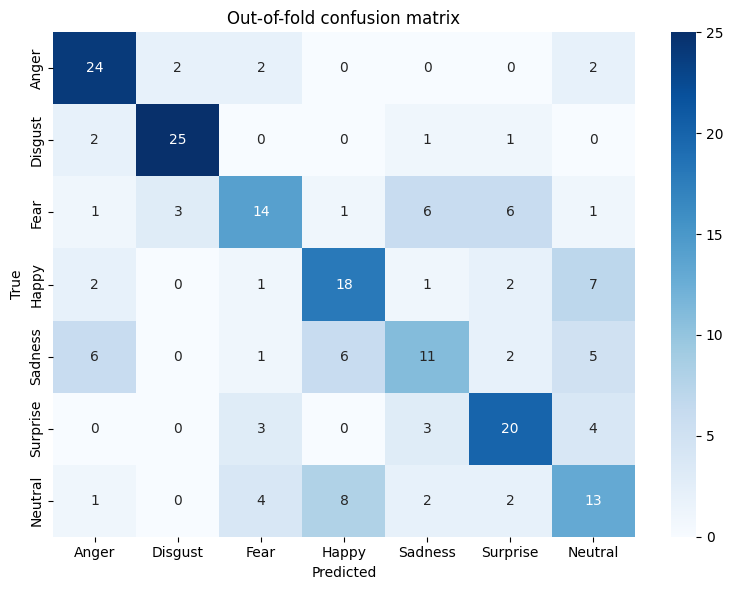

In [21]:
cm = confusion_matrix(all_true, all_pred, labels=np.arange(NUM_EMOTIONS))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=EMOTION_NAMES, yticklabels=EMOTION_NAMES, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Out-of-fold confusion matrix')
plt.tight_layout(); plt.show()

In [22]:
# # Rebuild only the best-fold model to create embeddings.
# best_fold = max(fold_results, key=lambda x: x['f1'])
# best_model, best_backbone = build_model()
# set_fine_tune_layers(best_backbone, FINE_TUNE_LAST_N)
# best_model.load_weights(best_fold['weights_path'])

# idxs = best_fold['val_idx']
# scaler_u = StandardScaler().fit(X_hog_upper[best_fold['train_idx']])
# scaler_l = StandardScaler().fit(X_hog_lower[best_fold['train_idx']])
# vis_inputs = make_inputs(idxs, scaler_u, scaler_l)

# # The shared CNN embedding is the 1280-D MobileNetV2 global-average-pooled representation.
# embedding_model = keras.Model(
#     inputs=best_backbone.input,
#     outputs=best_backbone.output,
#     name='MobileNetV2_embedding_extractor'
# )
# upper_cnn_embed = embedding_model.predict(vis_inputs[0], verbose=0)
# lower_cnn_embed = embedding_model.predict(vis_inputs[1], verbose=0)

# pca = PCA(n_components=2, random_state=SEED)
# upper_2d = pca.fit_transform(upper_cnn_embed)
# lower_2d = pca.transform(lower_cnn_embed)

# fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# for e in range(NUM_EMOTIONS):
#     m = labels[idxs] == e
#     ax[0].scatter(upper_2d[m,0], upper_2d[m,1], label=EMOTION_NAMES[e], alpha=0.8)
#     ax[1].scatter(lower_2d[m,0], lower_2d[m,1], label=EMOTION_NAMES[e], alpha=0.8)
# ax[0].set_title('Fine-tuned MobileNetV2 embeddings — upper region')
# ax[1].set_title('Fine-tuned MobileNetV2 embeddings — lower region')
# for a in ax:
#     a.set_xlabel('PC1'); a.set_ylabel('PC2'); a.grid(alpha=0.2)
# ax[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
# plt.tight_layout(); plt.show()
# print('PCA explained variance:', pca.explained_variance_ratio_)


##  Prediction confidence visualization

In [23]:
# confidence = all_prob.max(axis=1)
# correct = all_true == all_pred

# plt.figure(figsize=(9, 5))
# plt.hist(confidence[correct], bins=10, alpha=0.65, label='Correct')
# plt.hist(confidence[~correct], bins=10, alpha=0.65, label='Incorrect')
# plt.xlabel('Maximum softmax confidence')
# plt.ylabel('Number of samples')
# plt.title('Prediction confidence: correct vs incorrect')
# plt.legend(); plt.grid(alpha=0.2); plt.show()